<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# Sequential Orbit Determination — Complete Demo
---
*Scarabaeus OD Framework | Last revised 2026*

## What this notebook covers
Sequential orbit determination processes measurements **one at a time**, updating the
state estimate and covariance recursively at each epoch.  This is operationally efficient,
naturally handles process noise, and supports real-time processing.

For the full batch-filter catalogue (LSB, SRIF-Batch, corner plots, covariance propagation,
solution saving) see **`advanced_IdealMSR_BatchOD.ipynb`**.

### Topics
| # | Topic |
|---|-------|
| 1 | True trajectory and measurements (DSS-14 + DSS-63) |
| 2 | LKF with SNC process noise |
| 3 | Process noise theory — SNC vs. DMC |
| 4 | SRIF Sequential Filter |
| 5 | RTS smoother |
| 6 | Multi-leg OD with MissionSequence (two legs + impulsive burn) |
| 7 | Consider parameters (η_SRP) |
| 8 | Measurement editing — see BatchOD notebook |
| 9 | Solution saving and analysis — see BatchOD notebook |

## How to run
Run from the **project root** directory (`scarabaeus/`).


## 0. Imports and Setup

In [1]:
import os, sys
import numpy as np
import numpy.random as rnd
import matplotlib.pyplot as plt
from pathlib import Path

import scarabaeus as scb
import supplementary as supp

# ── tutorial data and output paths ───────────────────────────────
data = supp.load_data()

tut_result_path  = Path.cwd() / 'tutorial_results/meas_gen/radiometric'
tut_kernels_path = Path(data.mk.path).parent.parent / 'scenario'
tut_result_path.mkdir(parents=True, exist_ok=True)
tut_kernels_path.mkdir(parents=True, exist_ok=True)

kg, km, sec = scb.Units.get_units(['kg', 'km', 'sec'])
J2000, ITRF93, ECLIPJ2000, IAUEARTH = scb.Frame.generate_common_frames()
frame  = J2000
origin = scb.CelestialBody.from_constants('SUN')

scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.mk.path)
print("Kernels loaded.")

# ── common spacecraft & initial state ────────────────────────────
dry_mass  = scb.ArrayWUnits(1500.0, kg)
fuel_mass = scb.ArrayWUnits(500.0,  kg)
area      = scb.ArrayWUnits(1e-6,   km**2)
cr        = scb.ArrayWUnits(1.5,    None)

Orbiter = scb.Spacecraft('Orbiter_True', -2000,
                          dry_mass+fuel_mass, area, cr)

time_0      = scb.SpiceManager.jd2et(2461809.72995654 + 1/3)
time_f      = scb.SpiceManager.jd2et(2461809.72995654 + 3)
dt_step     = 30 * 60
epoch_array = scb.EpochArray(np.arange(time_0, time_f, dt_step), sys='TDB')
epoch_0     = epoch_array[0]

pos_0 = scb.ArrayWFrame(
    np.array([-1.1123095885148e+08, 8.9094345479316e+07, 3.8656500948069e+07]),
    km, frame)
vel_0 = scb.ArrayWFrame(
    np.array([-20.6936999825159, -16.7800270812616, -6.6437327193572]),
    km/sec, frame)


SCB supplementary data up to date.
Kernels loaded.


## Enhanced Plotting Helpers

The cells below add **calendar-date x-axis** versions of the plots above, plus new
visualization types: pre/post residual comparisons, state errors with ±3σ covariance
bounds, covariance evolution, and corner covariance plots.

Helper functions:
- `et2dt(et_arr)` — converts SPICE ET (seconds) to Python `datetime` objects
- `fmt_cal(ax)` — applies `AutoDateLocator + DateFormatter` for a clean calendar x-axis
- `add_hrs_axis(ax)` — adds a secondary top x-axis in hours from t0
- `resid_from_filter(flt, ds)` — extracts `(t_pre, r_pre, t_post, r_post)` arrays
- `corner_cov(P, labels)` — lower-triangle corner plot with RdBu_r correlation colouring


In [2]:
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import cm
from matplotlib.colors import Normalize

plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8,
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
})
CMAP = cm.tab10
COLORS = [CMAP(i / 10) for i in range(10)]

# reference epoch for the hours-from-t0 secondary axis
t0_et = epoch_array.times.values[0]


def et2dt(et_arr):
    """Convert SPICE ET seconds (TDB from J2000) to list of datetime objects."""
    _J2000 = datetime(2000, 1, 1, 12, 0, 0)
    return [_J2000 + timedelta(seconds=float(t)) for t in np.atleast_1d(et_arr)]


def fmt_cal(ax):
    """Apply calendar-date tick formatting to a matplotlib axis."""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=9))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))


def add_hrs_axis(ax, t0=None):
    """Add a secondary top x-axis showing hours from t0."""
    t0 = t0 if t0 is not None else t0_et
    from matplotlib.dates import date2num
    t0_num = date2num(et2dt([t0])[0])
    ax2 = ax.secondary_xaxis(
        "top",
        functions=(lambda x: (x - t0_num) * 24, lambda x: x / 24 + t0_num),
    )
    ax2.set_xlabel("Hours from t0 [TDB]", fontsize=8)
    ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f h"))
    return ax2


def resid_from_filter(flt_obj, ds_name, iteration=-1):
    """Return (t_pre, r_pre, t_post, r_post) numpy arrays for a dataset name.

    iteration : int
        Which iteration's pre-fit residuals to return.
        0  → first iteration (raw O-C against initial reference).
        -1 → last  iteration (default, same as the converged solution).
    Post-fit residuals always come from the final (converged) iteration.
    """
    if (iteration == 0
            and hasattr(flt_obj, '_solution_history')
            and flt_obj._solution_history):
        sol0 = flt_obj._solution_history[0]
        pre  = (sol0.prefits or {}).get(ds_name, [])
    else:
        pre  = flt_obj.prefit_residuals.get(ds_name, [])
    post = flt_obj.postfit_residuals.get(ds_name, [])
    t_ds = np.array([])
    for ds in flt_obj.measurement_data.datasets:
        if ds.set_name == ds_name:
            t_ds = np.array(ds.data["t2"])
            break
    t_pre  = t_ds[:len(pre)]  if len(pre)  else np.array([])
    r_pre  = np.array([d[0] for d in pre])  if pre  else np.array([])
    t_post = t_ds[:len(post)] if len(post) else np.array([])
    r_post = np.array([d[0] for d in post]) if post else np.array([])
    return t_pre, r_pre, t_post, r_post


def corner_cov(P, labels, title="Covariance Corner Plot", figsize=(10, 9)):
    """
    Corner plot from a covariance matrix.
    Diagonal: 1D Gaussian marginal (dark-shaded ±1σ region).
    Lower triangle: 2D confidence ellipses at 1σ / 2σ / 3σ  (chi2, 2 dof).
    Upper triangle: hidden.
    """
    from matplotlib.patches import Ellipse

    SCALES = [1.5150, 2.4477, 3.4395]
    ALPHAS = [0.55,   0.30,   0.15  ]
    COL, EDG = 'steelblue', 'navy'

    n   = P.shape[0]
    sig = np.sqrt(np.diag(P))

    fig, axes = plt.subplots(n, n, figsize=figsize,
                             gridspec_kw={'hspace': 0.05, 'wspace': 0.05})
    if n == 1:
        axes = np.array([[axes]])
    fig.suptitle(title, fontsize=11, fontweight='bold')

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            ax.tick_params(labelsize=5)

            if i == j:
                s   = sig[i]
                lim = 3.8 * s
                x   = np.linspace(-lim, lim, 300)
                y   = np.exp(-0.5 * (x / s) ** 2)
                ax.plot(x, y, color=COL, lw=1.5)
                ax.fill_between(x, y, alpha=0.18, color=COL)
                ax.fill_between(x[np.abs(x) <= s], y[np.abs(x) <= s],
                                alpha=0.45, color=COL)
                ax.axvline(0, color='k', lw=0.5, ls='--')
                ax.set_xlim(-lim, lim)
                ax.set_ylim(0, 1.30)
                ax.set_yticks([])
                ax.set_xticks([-2*s, 0, 2*s])
                ax.text(0.97, 0.97, f'1\u03c3={s:.2e}',
                        transform=ax.transAxes, fontsize=6,
                        ha='right', va='top', color=EDG, fontweight='bold')
                ax.set_title(labels[i], fontsize=7, pad=2)
                if i < n - 1:
                    ax.set_xticklabels([])

            elif i > j:
                P2       = np.array([[P[j,j], P[j,i]], [P[i,j], P[i,i]]])
                ev, evec = np.linalg.eigh(P2)
                ev       = np.maximum(ev, 0.0)
                angle    = np.degrees(np.arctan2(evec[1, 1], evec[0, 1]))
                ax.axhline(0, color='k', lw=0.4, ls='--', alpha=0.4)
                ax.axvline(0, color='k', lw=0.4, ls='--', alpha=0.4)
                for scale, alpha in zip(SCALES, ALPHAS):
                    ax.add_patch(Ellipse(
                        xy=(0, 0),
                        width =2 * scale * np.sqrt(ev[1]),
                        height=2 * scale * np.sqrt(ev[0]),
                        angle =angle,
                        facecolor=COL, edgecolor=EDG,
                        linewidth=0.8, alpha=alpha,
                    ))
                rho = P[i, j] / (sig[i] * sig[j])
                ax.text(0.05, 0.97, f'\u03c1={rho:+.2f}',
                        transform=ax.transAxes, fontsize=6.5,
                        color=EDG, va='top', fontweight='bold')
                ax.set_xlim(-3.8*sig[j], 3.8*sig[j])
                ax.set_ylim(-3.8*sig[i], 3.8*sig[i])
                ax.set_xticks([-2*sig[j], 0, 2*sig[j]])
                ax.set_yticks([-2*sig[i], 0, 2*sig[i]])
                if i < n - 1:
                    ax.set_xticklabels([])
                if j > 0:
                    ax.set_yticklabels([])
                if j == 0:
                    ax.set_ylabel(labels[i], fontsize=7, labelpad=2)
                if i == n - 1:
                    ax.set_xlabel(labels[j], fontsize=7, labelpad=2)

            else:
                ax.set_visible(False)

    plt.tight_layout()
    return fig


print(f"Plotting helpers ready.  t0 = {et2dt([t0_et])[0].strftime('%Y-%m-%d %H:%M:%S')} TDB")


Plotting helpers ready.  t0 = 2028-02-08 13:32:17 TDB


## 1. True Trajectory and Measurements

We propagate the truth and generate Range + RangeRate measurements on it (DSS-14).
These are the "observed" measurements the filter will try to explain.

The measurement generation is identical to the Batch notebook — see that notebook for the full
measurement-model catalogue (Doppler, DDOR, optical navigation).


In [3]:
# ── propagate truth ──────────────────────────────────────────────
third_bodies = ['MERCURY', 'VENUS', 'EARTH']

state_truth = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', Orbiter, pos_0),
    ('velocity', 3, 'estimated', 'dynamic', Orbiter, vel_0),
])
sv_truth = scb.StateArray(epoch=epoch_0, origin=origin, state=state_truth)
fm_truth = scb.ForceModelTranslation(primary_body=Orbiter,
                                      third_bodies=third_bodies, cannonball_SRP=True)
prop_truth = scb.Propagator(primary_body=Orbiter, state_vector=sv_truth,
                             tspan=epoch_array, force_models=fm_truth)
prop_truth.propagate()
state_prop_truth = prop_truth.propagated_state_array

true_spk = str(tut_kernels_path / 'seq_orbiter_true.bsp')
if os.path.isfile(true_spk): os.remove(true_spk)
orbiter_traj_true = scb.Trajectory(state_array=state_prop_truth)
orbiter_traj_true.write_to_spk(true_spk)
print("True trajectory saved.")

# ── ground stations ───────────────────────────────────────────────
GS1 = scb.GroundStation('DSS-14')
GS2 = scb.GroundStation('DSS-63')

range_sigma     = scb.ArrayWUnits(1e-3,  km)
rr_sigma        = scb.ArrayWUnits(1e-7,  km/sec)
rangerate_sigma = rr_sigma

Range_GS1     = scb.RangeIdeal('GS1 Range',    GS1, sigma=range_sigma)
RangeRate_GS1 = scb.RangeRateIdeal('GS1 RRate', GS1, sigma=rr_sigma)
Range_GS2     = scb.RangeIdeal('GS2 Range',    GS2, sigma=range_sigma)
RangeRate_GS2 = scb.RangeRateIdeal('GS2 RRate', GS2, sigma=rr_sigma)

for model, stem in [
    (Range_GS1,     'seq_range_GS1'),
    (RangeRate_GS1, 'seq_rr_GS1'),
    (Range_GS2,     'seq_range_GS2'),
    (RangeRate_GS2, 'seq_rr_GS2'),
]:
    model.write_observed_measurements(
        target=Orbiter, epoch_array=epoch_array, noisy=True,
        file_name=stem, check_visibility=True, elevation_mask=10.0,
        folder_path_override=str(tut_result_path))

obs_range = Range_GS1.observed_measurements(
    file_name=str(tut_result_path / 'seq_range_GS1.json'),
    meas_name='meas_ideal', units=km)
obs_rr    = RangeRate_GS1.observed_measurements(
    file_name=str(tut_result_path / 'seq_rr_GS1.json'),
    meas_name='meas_ideal', units=km/sec)
obs_range_GS2 = Range_GS2.observed_measurements(
    file_name=str(tut_result_path / 'seq_range_GS2.json'),
    meas_name='meas_ideal', units=km)
obs_rr_GS2    = RangeRate_GS2.observed_measurements(
    file_name=str(tut_result_path / 'seq_rr_GS2.json'),
    meas_name='meas_ideal', units=km/sec)

print(f"GS1 Range: {len(obs_range[2].quantity.values)} meas")
print(f"GS1 RRate: {len(obs_rr[2].quantity.values)} meas")
print(f"GS2 Range: {len(obs_range_GS2[2].quantity.values)} meas")
print(f"GS2 RRate: {len(obs_rr_GS2[2].quantity.values)} meas")



                            Starting propagation...                             


Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

Integrating:   0%|                                               | 0.01/230400.00 s [00:00<24:50:01]

Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

...

Integrating: 100%|█████████████████████████████████████████████| 230400.00/230400.00 s [00:00<00:00]

Integrating: 100%|█████████████████████████████████████████████| 230400.00/230400.00 s [00:00<00:00]

Integrating: 100%|█████████████████████████████████████████████| 230400.00/230400.00 s [00:00<00:00]

Integrating: 100%|█████████████████████████████████████████████| 230400.00/230400.00 s [00:00<00:00]


 =================== DOP853 integration complete. ==================
Propagation complete.
True trajectory saved.
GS1 Range: 69 meas
GS1 RRate: 69 meas
GS2 Range: 82 meas
GS2 RRate: 82 meas


## 2. LKF with SNC Process Noise

### Theory
The **Linearized Kalman Filter (LKF)** is the core sequential estimator.
At each measurement epoch $t_k$:

1. **Time update (predict):** propagate state and covariance forward with the STM
   $$\mathbf{P}_{k|k-1} = \mathbf{\Phi}_{k,k-1}\,\mathbf{P}_{k-1|k-1}\,\mathbf{\Phi}_{k,k-1}^T + \mathbf{Q}_k$$

2. **Measurement update (correct):** incorporate new measurement $y_k$
   $$\mathbf{K}_k = \mathbf{P}_{k|k-1}\,\mathbf{H}_k^T\,(\mathbf{H}_k\mathbf{P}_{k|k-1}\mathbf{H}_k^T + \mathbf{R}_k)^{-1}$$
   $$\hat{\mathbf{x}}_{k|k} = \hat{\mathbf{x}}_{k|k-1} + \mathbf{K}_k(y_k - \mathbf{H}_k\hat{\mathbf{x}}_{k|k-1})$$

### State Noise Compensation (SNC)
SNC models uncharacterised accelerations as **white noise** added continuously to the velocity:

$$\mathbf{Q}_k = \int_{t_{k-1}}^{t_k} \mathbf{\Phi}(t_k,\tau)\,\mathbf{B}\,q_c\,\mathbf{B}^T\,\mathbf{\Phi}(t_k,\tau)^T\,d\tau$$

where $q_c$ [km²/s³] is the **continuous-time noise spectral density**.

**Tuning Q_cont (SNC):**
- Too large → wide covariance, accepts noise, position sigma grows fast.
- Too small → filter stiffens, can't track maneuvers or unmodelled forces.
- Rule of thumb: $q_c \approx (\text{expected unmodelled accel})^2 / \text{arc length in sec}$

```python
Q_cont = scb.ProcessNoiseSettings(type='SNC', Q_cont=Q_cont_matrix)
```


In [4]:
# ── reference spacecraft (perturbed IC) ──────────────────────────
delta_pos_km  = np.array([1.0, 1.0, 1.0])     # 1 km error per axis
delta_vel_kms = np.array([1e-3, 1e-3, 1e-3])  # 1 m/s error per axis

def make_ref_sc(name, spice_id, d_pos, d_vel):
    sc  = scb.Spacecraft(name, spice_id, dry_mass+fuel_mass, area, cr)
    pos = scb.ArrayWFrame(pos_0.quantity + scb.ArrayWUnits(d_pos, km), frame)
    vel = scb.ArrayWFrame(vel_0.quantity + scb.ArrayWUnits(d_vel, km/sec), frame)
    return sc, pos, vel

sc_lkf, pos_lkf, vel_lkf = make_ref_sc('Orbiter_LKF', -2001,
                                         delta_pos_km, delta_vel_kms)

state_lkf = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', sc_lkf, pos_lkf),
    ('velocity', 3, 'estimated', 'dynamic', sc_lkf, vel_lkf),
])
sv_lkf = scb.StateArray(epoch=epoch_0, origin=origin, state=state_lkf)

fm_lkf = scb.ForceModelTranslation(
    primary_body=sc_lkf, third_bodies=third_bodies, cannonball_SRP=True)
prop_lkf = scb.Propagator(
    primary_body=sc_lkf, state_vector=sv_lkf,
    tspan=epoch_array, force_models=fm_lkf)

# ── initial covariance ────────────────────────────────────────────
pos_sig = scb.ArrayWUnits(3.0,   km)
vel_sig = scb.ArrayWUnits(3e-3,  km/sec)
P0 = scb.CovarianceMatrix(
    [pos_sig]*3 + [vel_sig]*3, epoch_array[1], from_list=True)

# ── SNC process noise ─────────────────────────────────────────────
Q_diag = scb.ArrayWUnits(1e-9**2, km**2 * sec**-4)
Q_cont = scb.CovarianceMatrix([Q_diag]*3, epoch_array[0], from_list=True)
pn_snc = scb.ProcessNoiseSettings(type='SNC', Q_cont=Q_cont)

# ── measurement list ──────────────────────────────────────────────
meas_lkf = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1,     observed_meas=obs_range,
                        dataset_name='GS1 Range'),
    scb.MeasurementSpec(model=RangeRate_GS1, observed_meas=obs_rr,
                        dataset_name='GS1 RangeRate'),
    scb.MeasurementSpec(model=Range_GS2,     observed_meas=obs_range_GS2,
                        dataset_name='GS2 Range'),
    scb.MeasurementSpec(model=RangeRate_GS2, observed_meas=obs_rr_GS2,
                        dataset_name='GS2 RangeRate'),
)

# ── LKF ──────────────────────────────────────────────────────────
ref_spk_lkf = tut_kernels_path / 'seq_orbiter_ref_lkf.bsp'
if ref_spk_lkf.exists(): ref_spk_lkf.unlink()

lkf = scb.LKF(
    propagator   = prop_lkf,
    settings     = scb.FilterSettings(
        initial_covariance = P0,
        process_noise      = pn_snc,
        output             = scb.OutputSettings(metadata={'filter':'LKF-SNC'}),
    ),
    measurements = meas_lkf,
    traj_name    = 'seq_orbiter_ref_lkf.bsp',
    traj_dir     = str(tut_kernels_path),
)
print("Running LKF with SNC ...")
sol_lkf, ni_lkf, conv_lkf = lkf.fit(
    max_iterations        = 10,
    convergence_threshold = 1e-6,
    verbose               = True,
    traj_name             = 'seq_orbiter_ref_lkf.bsp',
    traj_dir              = str(tut_kernels_path),
    if_sequential_smooth  = False,
)
print(f"Converged: {conv_lkf} after {ni_lkf} iterations")



                            Starting propagation...                             


Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

Integrating:   0%|                                               | 0.01/230400.00 s [00:00<20:47:11]

Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

...

Partials:  99%|███████████████████████████████████████████████████████████▎| 81/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]


ITERATION 3
[886905137.43 TDB |   0.0%] ‖prefit‖ = 9.5495e-04   ‖postfit‖ = 5.6702e-11   ‖update‖ = 9.5556e-04   tr(P) = 2.5111e+02   √tr(S) = 1.1214e+01   ⟨std⟩ = 5.00e-04
[886906937.43 TDB |   0.8%] ‖prefit‖ = 1.2760e-03   ‖postfit‖ = 1.6097e-04   ‖update‖ = 7.8652e-01   tr(P) = 2.8869e+02   √tr(S) = 8.5159e-03   ⟨std⟩ = 5.00e-04
[886908737.43 TDB |   1.6%] ‖prefit‖ = 6.7254e-04   ‖postfit‖ = 1.1071e-03   ‖update‖ = 5.2260e+00   tr(P) = 6.6982e+01   √tr(S) = 1.7504e-03   ⟨std⟩ = 5.00e-04
[886910537.43 TDB |   2.4%] ‖prefit‖ = 4.4333e-04   ‖postfit‖ = 9.0294e-05   ‖update‖ = 7.9603e+00   tr(P) = 7.5455e+01   √tr(S) = 1.2295e-03   ⟨std⟩ = 5.00e-04
[886912337.43 TDB |   3.2%] ‖prefit‖ = 4.8503e-04   ‖postfit‖ = 1.5761e-05   ‖update‖ = 4.3491e+00   tr(P) = 6.7828e+01   √tr(S) = 1.1792e-03   ⟨std⟩ = 5.00e-04
[886914137.43 TDB |   4.0%] ‖prefit‖ = 2.6005e-04   ‖postfit‖ = 5.8373e-04   ‖update‖ = 1.1672e+01   tr(P) = 4.3794e+01   √tr(S) = 1.1593e-03   ⟨std⟩ = 5.00e-04
[886915937.43 TDB |  

#### Enhanced: LKF (SNC) — Pre-fit vs Post-fit Residuals (Calendar Date)


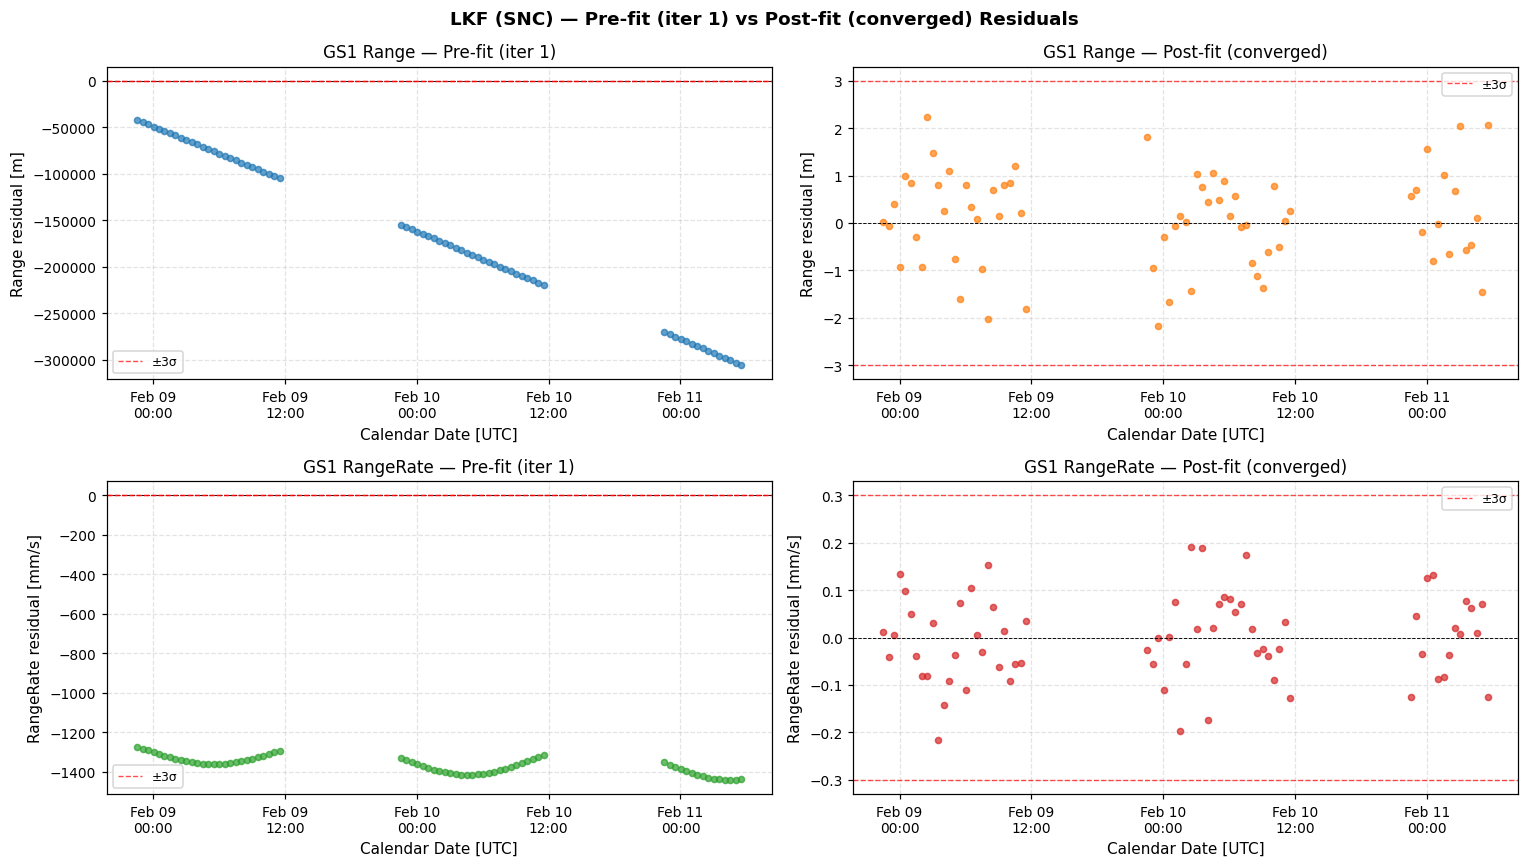

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("LKF (SNC) — Pre-fit (iter 1) vs Post-fit (converged) Residuals",
             fontsize=12, fontweight="bold")

for row, (ds_name, sigma_val, ylabel) in enumerate([
    ("GS1 Range",    float(range_sigma.values) * 1e3,  "Range residual [m]"),
    ("GS1 RangeRate",float(rr_sigma.values)    * 1e6,  "RangeRate residual [mm/s]"),
]):
    scale = 1e3 if row == 0 else 1e6
    t_pre,  r_pre,  _,      _      = resid_from_filter(lkf, ds_name, iteration=0)
    _,      _,      t_post, r_post = resid_from_filter(lkf, ds_name)
    for col, (t_r, r_r, label) in enumerate(
        [(t_pre, r_pre, "Pre-fit (iter 1)"), (t_post, r_post, "Post-fit (converged)")]
    ):
        ax = axes[row, col]
        if len(t_r):
            ax.plot(et2dt(t_r), r_r * scale, ".", ms=8, color=COLORS[row*2+col], alpha=0.7)
            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.axhline( 3 * sigma_val, color="r", lw=0.9, ls="--", alpha=0.7, label="±3σ")
            ax.axhline(-3 * sigma_val, color="r", lw=0.9, ls="--", alpha=0.7)
        ax.set_title(f"{ds_name} — {label}")
        ax.set_ylabel(ylabel); ax.set_xlabel("Calendar Date [UTC]")
        fmt_cal(ax); ax.legend()

plt.tight_layout(); plt.show()


## 3. Process Noise Theory — SNC vs. DMC

Sequential filters use **process noise** to account for unmodelled accelerations.

| Model | State size | Best for |
|-------|-----------|----------|
| **SNC** — white noise on velocity | unchanged (6) | short arcs, well-modelled dynamics |
| **DMC** — FOGM stochastic acceleration | +3 (augmented) | long arcs with slow-varying unmodelled forces |

```python
# SNC — no state augmentation
pn = scb.ProcessNoiseSettings(type='SNC', Q_cont=Q_matrix)

# DMC — augmented state with FOGM acceleration
pn = scb.ProcessNoiseSettings(type='DMC', Q_cont=Q_matrix,
                               beta=force_model.fogm_beta)
```

The FOGM+DMC implementation (with `first_order_gauss_markov=True` and stochastic
acceleration time-series plots) is demonstrated in `advanced_IdealMSR_BatchOD.ipynb`.
This notebook uses SNC throughout.


## 4. SRIF Sequential Filter

The **Square-Root Information Filter (SRIF)** is the numerically most stable sequential algorithm.
Instead of propagating the covariance **P**, it propagates the square root of the information
matrix **R = P⁻¹**, avoiding the numerical issues associated with covariance inversion.

SRIF is preferred when:
- The state dimension is large (many parameters)
- Long arcs with many measurements accumulate numerical error in P
- Near-singular covariance matrices arise (highly correlated parameters)

API is identical to LKF — just swap `scb.LKF` for `scb.SRIF`.


In [6]:
# ── SRIF — reuse the same reference setup as LKF ────────────────
sc_srif, pos_srif, vel_srif = make_ref_sc('Orbiter_SRIF', -2003,
                                            delta_pos_km, delta_vel_kms)
state_srif = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', sc_srif, pos_srif),
    ('velocity', 3, 'estimated', 'dynamic', sc_srif, vel_srif),
])
sv_srif   = scb.StateArray(epoch=epoch_0, origin=origin, state=state_srif)
fm_srif   = scb.ForceModelTranslation(primary_body=sc_srif,
                                       third_bodies=third_bodies, cannonball_SRP=True)
prop_srif = scb.Propagator(primary_body=sc_srif, state_vector=sv_srif,
                            tspan=epoch_array, force_models=fm_srif)

meas_srif = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1,     observed_meas=obs_range,
                        dataset_name='GS1 Range'),
    scb.MeasurementSpec(model=RangeRate_GS1, observed_meas=obs_rr,
                        dataset_name='GS1 RangeRate'),
    scb.MeasurementSpec(model=Range_GS2,     observed_meas=obs_range_GS2,
                        dataset_name='GS2 Range'),
    scb.MeasurementSpec(model=RangeRate_GS2, observed_meas=obs_rr_GS2,
                        dataset_name='GS2 RangeRate'),
)

ref_spk_srif = tut_kernels_path / 'seq_orbiter_ref_srif.bsp'
if ref_spk_srif.exists(): ref_spk_srif.unlink()

srif = scb.SRIF(
    propagator   = prop_srif,
    settings     = scb.FilterSettings(
        initial_covariance = P0,
        process_noise      = pn_snc,
        output             = scb.OutputSettings(metadata={'filter':'SRIF-SNC'}),
    ),
    measurements = meas_srif,
    traj_name    = 'seq_orbiter_ref_srif.bsp',
    traj_dir     = str(tut_kernels_path),
)
print("Running SRIF ...")
sol_srif, ni_srif, conv_srif = srif.fit(
    max_iterations=5, convergence_threshold=1e-6, verbose=True,
    traj_name='seq_orbiter_ref_srif.bsp',
    traj_dir=str(tut_kernels_path),
)
print(f"SRIF converged: {conv_srif} after {ni_srif} iterations")



                            Starting propagation...                             


Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

Integrating:   0%|                                               | 0.01/230400.00 s [00:00<20:28:21]

Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

...

Partials:  99%|███████████████████████████████████████████████████████████▎| 81/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]


ITERATION 3
[886905137.43 TDB |   0.0%] ‖prefit‖=9.5498e-04   ‖postfit‖=5.6710e-11   tr(P)=2.5111e+02   ⟨σ⟩=5.00e-04
[886906937.43 TDB |   0.8%] ‖prefit‖=1.2760e-03   ‖postfit‖=1.6097e-04   tr(P)=2.8869e+02   ⟨σ⟩=5.00e-04
[886908737.43 TDB |   1.6%] ‖prefit‖=6.7257e-04   ‖postfit‖=1.1071e-03   tr(P)=6.6982e+01   ⟨σ⟩=5.00e-04
[886910537.43 TDB |   2.4%] ‖prefit‖=4.4330e-04   ‖postfit‖=9.0295e-05   tr(P)=7.5455e+01   ⟨σ⟩=5.00e-04
[886912337.43 TDB |   3.2%] ‖prefit‖=4.8497e-04   ‖postfit‖=1.5751e-05   tr(P)=6.7828e+01   ⟨σ⟩=5.00e-04
[886914137.43 TDB |   4.0%] ‖prefit‖=2.6014e-04   ‖postfit‖=5.8375e-04   tr(P)=4.3794e+01   ⟨σ⟩=5.00e-04
[886915937.43 TDB |   4.8%] ‖prefit‖=1.8850e-04   ‖postfit‖=3.5017e-04   tr(P)=2.6062e+01   ⟨σ⟩=5.00e-04
[886917737.43 TDB |   5.6%] ‖prefit‖=1.3456e-04   ‖postfit‖=1.8525e-04   tr(P)=1.7244e+01   ⟨σ⟩=5.00e-04
[886919537.43 TDB |   6.3%] ‖prefit‖=7.4986e-04   ‖postfit‖=6.9522e-04   tr(P)=1.3018e+01   ⟨σ⟩=5.00e-04
[886921337.43 TDB |   7.1%] ‖prefit‖=9.073

## 5. RTS Smoother

The **Rauch-Tung-Striebel (RTS) smoother** runs a backward pass after the forward Kalman filter
to refine estimates at *earlier* epochs using measurements from *later* epochs.

- The forward filter is causal: at $t_k$ it uses only measurements $t \leq t_k$.
- The smoother is acausal: at $t_k$ it uses **all** measurements in the arc.

Enable it by passing `if_sequential_smooth=True` to `filter.fit()`.
The smoothed solution is stored in `solution.deviation_smooth` and `solution.covariance_smooth`.

**When to use:** post-processing after all data are collected.
**Not applicable for:** real-time navigation (forward-only).



                            Starting propagation...                             


Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

Integrating:   0%|                                               | 0.01/230400.00 s [00:00<37:32:06]

Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

...

Partials:  99%|███████████████████████████████████████████████████████████▎| 81/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]


ITERATION 5
[886905137.43 TDB |   0.0%] ‖prefit‖ = 8.6200e-04   ‖postfit‖ = 4.9521e-11   ‖update‖ = 8.6250e-04   tr(P) = 2.5111e+02   √tr(S) = 1.1214e+01   ⟨std⟩ = 5.00e-04
[886906937.43 TDB |   0.8%] ‖prefit‖ = 1.1688e-03   ‖postfit‖ = 1.6097e-04   ‖update‖ = 7.8651e-01   tr(P) = 2.8869e+02   √tr(S) = 8.5159e-03   ⟨std⟩ = 5.00e-04
[886908737.43 TDB |   1.6%] ‖prefit‖ = 7.9405e-04   ‖postfit‖ = 1.1071e-03   ‖update‖ = 5.2259e+00   tr(P) = 6.6982e+01   √tr(S) = 1.7504e-03   ⟨std⟩ = 5.00e-04
[886910537.43 TDB |   2.4%] ‖prefit‖ = 3.0746e-04   ‖postfit‖ = 9.0312e-05   ‖update‖ = 7.9603e+00   tr(P) = 7.5455e+01   √tr(S) = 1.2295e-03   ⟨std⟩ = 5.00e-04
[886912337.43 TDB |   3.2%] ‖prefit‖ = 3.3474e-04   ‖postfit‖ = 1.5744e-05   ‖update‖ = 4.3491e+00   tr(P) = 6.7828e+01   √tr(S) = 1.1792e-03   ⟨std⟩ = 5.00e-04
[886914137.43 TDB |   4.0%] ‖prefit‖ = 4.2483e-04   ‖postfit‖ = 5.8376e-04   ‖update‖ = 1.1672e+01   tr(P) = 4.3794e+01   √tr(S) = 1.1593e-03   ⟨std⟩ = 5.00e-04
[886915937.43 TDB |  

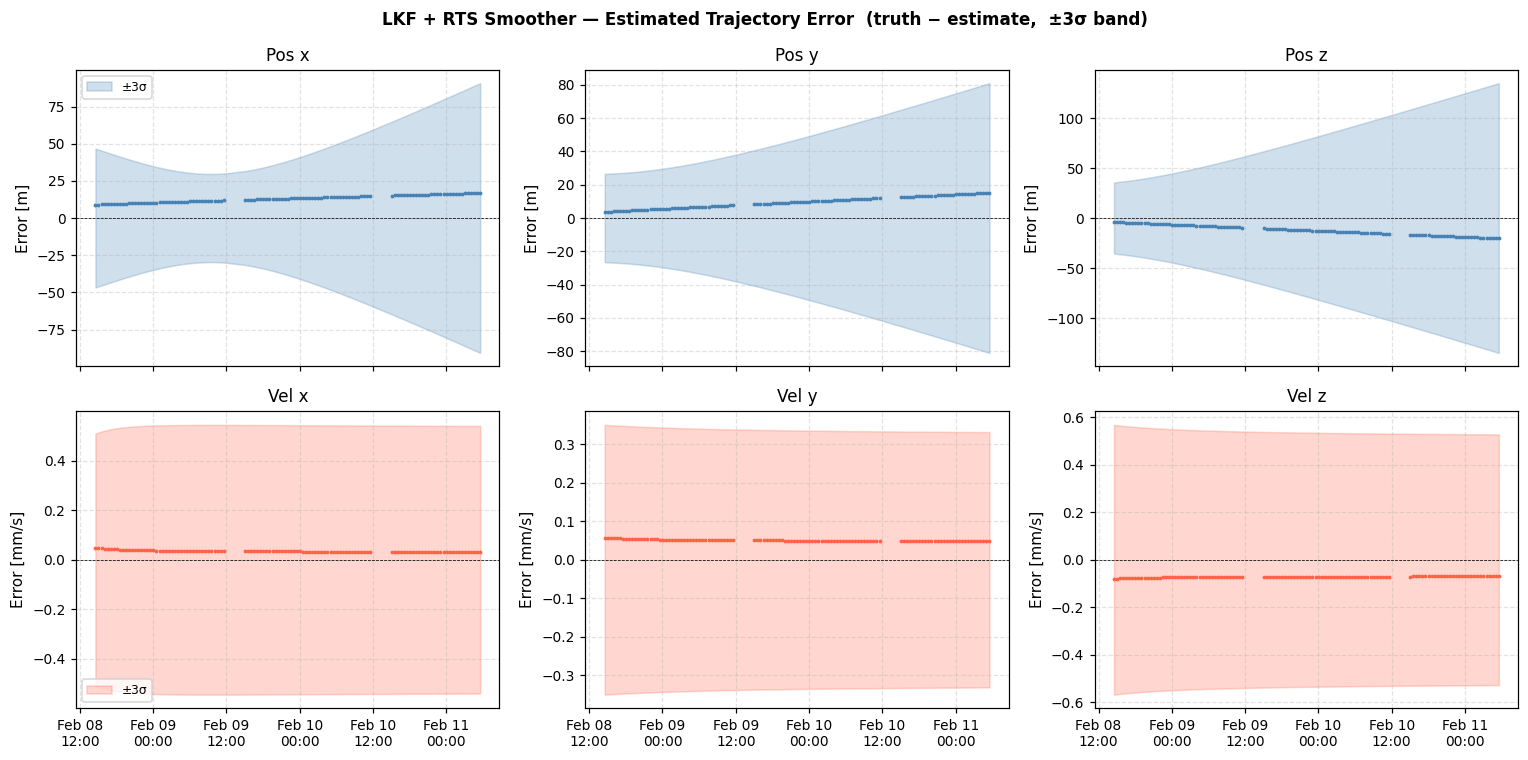

RTS Smoother — RMS position error : 12.19 m
RTS Smoother — RMS velocity error : 0.0549 mm/s


In [7]:
# ── LKF + RTS smoother ───────────────────────────────────────────
sc_sm, pos_sm, vel_sm = make_ref_sc('Orbiter_Smooth', -2004,
                                     delta_pos_km, delta_vel_kms)
state_sm = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', sc_sm, pos_sm),
    ('velocity', 3, 'estimated', 'dynamic', sc_sm, vel_sm),
])
sv_sm   = scb.StateArray(epoch=epoch_0, origin=origin, state=state_sm)
fm_sm   = scb.ForceModelTranslation(primary_body=sc_sm,
                                     third_bodies=third_bodies, cannonball_SRP=True)
prop_sm = scb.Propagator(primary_body=sc_sm, state_vector=sv_sm,
                          tspan=epoch_array, force_models=fm_sm)

meas_sm = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1,     observed_meas=obs_range,
                        dataset_name='GS1 Range'),
    scb.MeasurementSpec(model=RangeRate_GS1, observed_meas=obs_rr,
                        dataset_name='GS1 RangeRate'),
    scb.MeasurementSpec(model=Range_GS2,     observed_meas=obs_range_GS2,
                        dataset_name='GS2 Range'),
    scb.MeasurementSpec(model=RangeRate_GS2, observed_meas=obs_rr_GS2,
                        dataset_name='GS2 RangeRate'),
)

ref_spk_sm = tut_kernels_path / 'seq_orbiter_ref_smooth.bsp'
if ref_spk_sm.exists(): ref_spk_sm.unlink()

lkf_sm = scb.LKF(
    propagator   = prop_sm,
    settings     = scb.FilterSettings(
        initial_covariance = P0,
        process_noise      = pn_snc,
        output             = scb.OutputSettings(metadata={'filter':'LKF-SNC-Smooth'}),
    ),
    measurements = meas_sm,
    traj_name    = 'seq_orbiter_ref_smooth.bsp',
    traj_dir     = str(tut_kernels_path),
)
print("Running LKF + RTS smoother ...")
sol_sm, ni_sm, conv_sm = lkf_sm.fit(
    max_iterations       = 5,
    convergence_threshold= 1e-6,
    verbose              = True,
    traj_name            = 'seq_orbiter_ref_smooth.bsp',
    traj_dir             = str(tut_kernels_path),
    if_sequential_smooth = True,    # ← enable RTS smoother
)
print(f"LKF+Smoother converged: {conv_sm} after {ni_sm} iterations")

# ── LKF + RTS Smoother — state errors vs truth (custom 2×3 plot) ─
et_sm_arr = sol_sm.timestamps
meas_ep_sm_plot = scb.EpochArray(et_sm_arr, sys='TDB')

est_pos_sm, est_vel_sm, _ = sol_sm.estimated_trajectory(meas_ep_sm_plot)

true_pos_sm = np.array([
    np.asarray(orbiter_traj_true.get_state(meas_ep_sm_plot[k])['position'].values)
    for k in range(len(et_sm_arr))
])
true_vel_sm = np.array([
    np.asarray(orbiter_traj_true.get_state(meas_ep_sm_plot[k])['velocity'].values)
    for k in range(len(et_sm_arr))
])

err_pos_sm_m  = (est_pos_sm - true_pos_sm) * 1e3    # km → m
err_vel_sm_mm = (est_vel_sm - true_vel_sm) * 1e6    # km/s → mm/s

P_sm_plot = sol_sm.propagate_covariance(meas_ep_sm_plot)
sig_pos_sm = np.array([np.sqrt(np.diag(P)[:3]) for P in P_sm_plot]) * 1e3
sig_vel_sm = np.array([np.sqrt(np.diag(P)[3:6]) for P in P_sm_plot]) * 1e6

dts_sm_plot = et2dt(et_sm_arr)
comp = ['x', 'y', 'z']

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
fig.suptitle('LKF + RTS Smoother — Estimated Trajectory Error  (truth − estimate,  ±3σ band)',
             fontweight='bold', fontsize=11)

for j in range(3):
    for row, (err, sig, unit, col) in enumerate([
        (err_pos_sm_m[:, j],  sig_pos_sm[:, j],  'm',    'steelblue'),
        (err_vel_sm_mm[:, j], sig_vel_sm[:, j],  'mm/s', 'tomato'),
    ]):
        ax = axes[row, j]
        ax.plot(dts_sm_plot, err, '.', color=col, ms=3, lw=0.8)
        ax.fill_between(dts_sm_plot, -3*sig, 3*sig, alpha=0.25, color=col, label='±3σ')
        ax.axhline(0, color='k', lw=0.5, ls='--')
        lbl = f'Pos {comp[j]}' if row == 0 else f'Vel {comp[j]}'
        ax.set_title(lbl); ax.set_ylabel(f'Error [{unit}]')
        fmt_cal(ax)
        if j == 0: ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

rms_pos_sm = np.sqrt(np.mean(err_pos_sm_m**2))
rms_vel_sm = np.sqrt(np.mean(err_vel_sm_mm**2))
print(f"RTS Smoother — RMS position error : {rms_pos_sm:.2f} m")
print(f"RTS Smoother — RMS velocity error : {rms_vel_sm:.4f} mm/s")


## 6. Multi-Leg OD with MissionSequence — Covariance Analysis

> **This section runs a linear covariance analysis — no actual measurements are needed.**
> A single LKF pass (`max_iterations=1`) propagates the error covariance through the
> measurement geometry without processing any real residuals.  The result shows how
> tracking coverage reduces position/velocity uncertainty and how ΔV uncertainty
> couples into the post-burn state.

Real missions often have **maneuvers** (delta-v burns) during the tracking arc.
A `MissionSequence` chains together trajectory legs separated by burn events.

### Structure
```
Leg 1  →  [Impulsive Burn]  →  Leg 2
  6-state P                    9-state P  (pos + vel + dv_man)
```

The burn is modelled as an **impulsive ΔV** applied instantaneously at the node.
The filter maps the covariance across the node and augments the state with the burn
vector `dv_man` as an **estimated parameter** — its a priori uncertainty (here ±0.1 m/s)
inflates the post-burn covariance.

### Why covariance analysis?
| Full OD (`max_iterations > 1`) | Covariance analysis (`max_iterations=1`) |
|-------------------------------|------------------------------------------|
| Needs real observed measurements | Needs measurement epochs, geometry, and weights |
| Estimates corrections to the reference | Propagates P only — no state update |
| Tests filter convergence | Tests observability and uncertainty budget |

### Key API
```python
ImpulsiveBurn(delta_v=ArrayWFrame(...))   # vector API — required for dv_man linkage
StateDefinition.empty_pv(...).param('dv_man', sc, dv_vec,
                                    estimation='estimated', dynamics='static')
CovarianceMatrix(..., extra_apriori_sigmas={'dv_man': sigma_vec})
MeasurementSpec.from_dict([{'model': ..., 'dataset_name': ..., 'epochs': epoch_arr}])
lkf.fit(max_iterations=1)               # single pass = linear covariance analysis


In [8]:
# ── multi-leg: 2 legs + 1 impulsive burn midway ──────────────────
sc_ms = scb.Spacecraft('Orbiter_MS', -2005, dry_mass+fuel_mass, area, cr)

# Epoch setup — split the arc in two equal halves
time_mid   = scb.SpiceManager.jd2et(2461809.72995654 + 1/3 + 1.5)
leg_period = scb.ArrayWUnits(float(time_mid - time_0), sec)
leg_dt     = scb.ArrayWUnits(dt_step, sec)

pos_ms = scb.ArrayWFrame(pos_0.quantity + scb.ArrayWUnits(delta_pos_km, km), frame)
vel_ms = scb.ArrayWFrame(vel_0.quantity + scb.ArrayWUnits(delta_vel_kms, km/sec), frame)

# ── Leg 1 state ───────────────────────────────────────────────────
leg1_model = scb.StateArray(
    epoch=epoch_0, origin=origin,
    state=scb.StateDefinition.from_components([
        ('position', 3, 'estimated', 'dynamic', sc_ms, pos_ms),
        ('velocity', 3, 'estimated', 'dynamic', sc_ms, vel_ms),
    ])
)

# ── Impulsive burn — must use delta_v=ArrayWFrame (not magnitude+direction)
# so the same vector object can be linked to the dv_man parameter in leg 2.
dv_ms = scb.ArrayWFrame(scb.ArrayWUnits(np.array([1e-3, 0.0, 0.0]), km/sec), frame)
burn  = scb.ImpulsiveBurn(delta_v=dv_ms)

# ── Leg 2 state — includes dv_man as an *estimated* parameter ─────
leg2_model = scb.StateArray(
    epoch  = scb.EpochArray(np.zeros(1), sys='TDB'),
    origin = origin,
    state  = scb.StateDefinition.empty_pv(sc_ms, frame=frame).param(
        'dv_man', sc_ms, dv_ms, estimation='estimated', dynamics='static'
    ),
)

# ── force models and propagators ──────────────────────────────────
fm_ms     = scb.ForceModelTranslation(primary_body=sc_ms,
                                       third_bodies=third_bodies, cannonball_SRP=True)
prop_leg1 = scb.Propagator(primary_body=sc_ms, state_vector=leg1_model,
                            tspan=epoch_array, force_models=fm_ms)
prop_leg2 = scb.Propagator(primary_body=sc_ms, state_vector=leg2_model,
                            tspan=epoch_array, force_models=fm_ms)

# ── assemble and propagate ────────────────────────────────────────
MS = scb.MissionSequence('SeqDemo')
MS.addLeg( 'Leg1',  leg_period, leg1_model, prop_leg1, leg_dt)
MS.addBurn('DVBurn', burn,                  prop_leg1)
MS.addLeg( 'Leg2',  leg_period, leg2_model, prop_leg2, leg_dt)

print("Propagating MissionSequence ...")
Scenario = MS.propagate()

ms_spk = str(tut_kernels_path / 'seq_orbiter_ms_ref.bsp')
if os.path.isfile(ms_spk): os.remove(ms_spk)
traj_ms = scb.Trajectory(leg_array=Scenario)
traj_ms.write_to_spk(ms_spk)
traj_ms.add_STMs(Scenario.STM)
print(f"MissionSequence propagated — {len(Scenario.total_epochsTDB.times.values)} epochs, "
      f"burn at {et2dt([float(time_mid)])[0].strftime('%Y-%m-%d %H:%M')} UTC")


Propagating MissionSequence ...

--- Propagating Segment 1/3: 'Leg1' [Leg] ---

[IC] segment='Leg1' type='Leg' epoch=886901537.4300113 sec (TDB)
  position     n= 3 sid=-2005 frame=J2000 vals[:6]=[-1.11230958e+08  8.90943465e+07  3.86565019e+07]
  velocity     n= 3 sid=-2005 frame=J2000 vals[:6]=[-20.69269998 -16.77902708  -6.64273272]

                            Starting propagation...                             


Integrating:   0%|                                                      | 0.00/129600.00 s [00:00<?]

Integrating:   0%|                                                      | 0.00/129600.00 s [00:00<?]

Integrating:   0%|                                               | 0.01/129600.00 s [00:00<11:02:17]

Integrating:   0%|                                                      | 0.00/129600.00 s [00:00<?]

...

Integrating: 100%|█████████████████████████████████████████████| 129600.00/129600.00 s [00:00<00:00]

Integrating: 100%|█████████████████████████████████████████████| 129600.00/129600.00 s [00:00<00:00]

Integrating: 100%|█████████████████████████████████████████████| 129600.00/129600.00 s [00:00<00:00]

Integrating: 100%|█████████████████████████████████████████████| 129600.00/129600.00 s [00:00<00:00]


 =================== DOP853 integration complete. ==================
Propagation complete.

[GLOBAL STATE after 'Leg2']
  key=('position', 3, -2005, 'J2000', 0) -> global[0:3] = [-1.16427973e+08  8.45342745e+07  3.68220032e+07]
  key=('velocity', 3, -2005, 'J2000', 0) -> global[3:6] = [-19.4314956  -18.13413842  -7.32966118]
  key=('dv_man', 3, -2005, 'J2000', 0) -> global[6:9] = [0.001 0.    0.   ]
MissionSequence propagated — 147 epochs, burn at 2028-02-10 01:32 UTC


In [9]:
# ── MissionSequence — impulsive burn covariance analysis ─────────
# Linear covariance analysis:  max_iterations=1, no real observations.
# The LKF propagates P through the measurement geometry only.
#
# dv_man is a 3-component considered parameter whose a priori sigma
# (10% of the 1 m/s nominal burn) inflates the state covariance.
# Tracking data reduces position/velocity uncertainty, but the ΔV
# uncertainty is only constrained via the post-burn trajectory.

# a priori ΔV uncertainty: ±0.1 m/s (1e-4 km/s) per axis = 10% of nominal
dv_sig_ms = scb.ArrayWUnits(np.array([1e-4, 1e-4, 1e-4]), km/sec)

P0_ms = scb.CovarianceMatrix(
    [pos_sig]*3 + [vel_sig]*3,
    epoch_array[1], from_list=True,
    extra_apriori_sigmas={'dv_man': dv_sig_ms},
)

# Measurement geometry — epochs only, no observed data required for cov analysis
cov_times  = np.array(Scenario.total_epochsTDB.times.values)
cov_epochs = scb.EpochArray(cov_times, sys='TDB')

Range_GS1_ms = scb.RangeIdeal('GS1 Range MS', GS1,
                                sigma=range_sigma, sequence_definition=MS)
RR_GS1_ms    = scb.RangeRateIdeal('GS1 RRate MS', GS1,
                                   sigma=rr_sigma,  sequence_definition=MS)

meas_ms = scb.MeasurementSpec.from_dict([
    {'model': Range_GS1_ms, 'dataset_name': 'GS1 Range MS', 'epochs': cov_epochs},
    {'model': RR_GS1_ms,    'dataset_name': 'GS1 RRate MS', 'epochs': cov_epochs},
])

ref_spk_ms = tut_kernels_path / 'seq_orbiter_ref_ms.bsp'
if ref_spk_ms.exists(): ref_spk_ms.unlink()

lkf_ms = scb.LKF(
    propagator   = MS,
    settings     = scb.FilterSettings(
        initial_covariance = P0_ms,
        output             = scb.OutputSettings(metadata={'filter':'LKF-MS-CovAnalysis'}),
    ),
    measurements = meas_ms,
    traj_name    = 'seq_orbiter_ref_ms.bsp',
    traj_dir     = str(tut_kernels_path),
)
print("Running covariance analysis (single pass) ...")
sol_ms, ni_ms, conv_ms = lkf_ms.fit(
    max_iterations=1, verbose=False,
    traj_name='seq_orbiter_ref_ms.bsp',
    traj_dir=str(tut_kernels_path),
)
print(f"Done — {ni_ms} iteration, {len(sol_ms.timestamps)} measurement epochs processed")



--- Propagating Segment 1/3: 'Leg1' [Leg] ---

[IC] segment='Leg1' type='Leg' epoch=886901537.4300113 sec (TDB)
  position     n= 3 sid=-2005 frame=J2000 vals[:6]=[-1.11230958e+08  8.90943465e+07  3.86565019e+07]
  velocity     n= 3 sid=-2005 frame=J2000 vals[:6]=[-20.69269998 -16.77902708  -6.64273272]

                            Starting propagation...                             


Integrating:   0%|                                                      | 0.00/129600.00 s [00:00<?]

Integrating:   0%|                                                      | 0.00/129600.00 s [00:00<?]

Integrating:   0%|                                               | 0.01/129600.00 s [00:00<11:08:44]

Integrating:   0%|                                                      | 0.00/129600.00 s [00:00<?]

...

Partials:  99%|█████████████████████████████████████████████████████████▌| 146/147 obs [00:00<00:00]

Partials: 100%|██████████████████████████████████████████████████████████| 147/147 obs [00:00<00:00]

Partials: 100%|██████████████████████████████████████████████████████████| 147/147 obs [00:00<00:00]

Partials: 100%|██████████████████████████████████████████████████████████| 147/147 obs [00:00<00:00]


Initializing Linearized Kalman Filter (LKF)
Running covariance analysis (single pass) ...
Event detected at epoch 887031137.4300463 [TDB]: re-initializing the filter at this epoch.
Done — 1 iteration, 147 measurement epochs processed


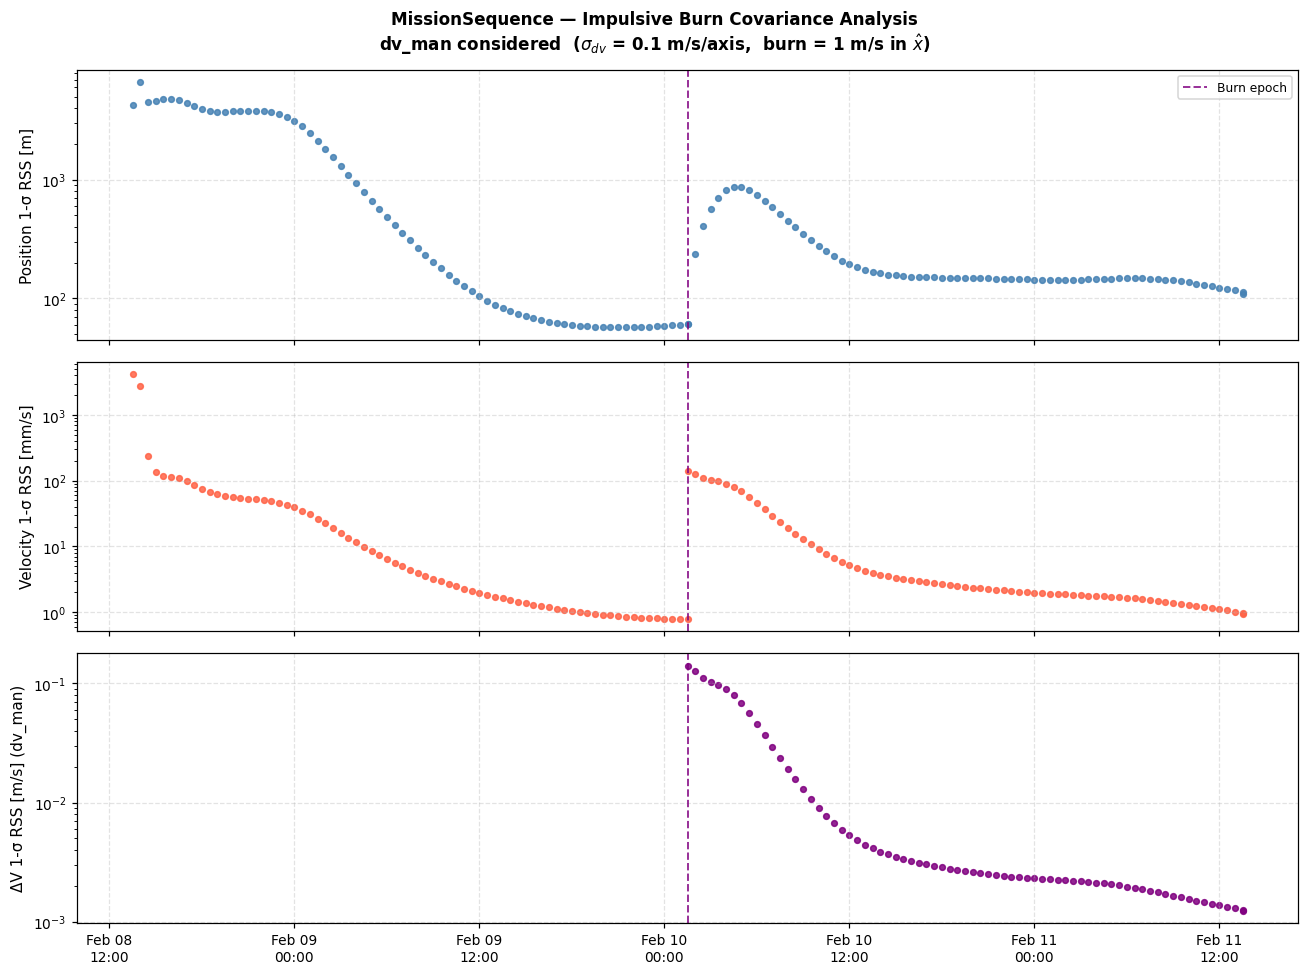

Initial  pos σ : 4243 m    →  final: 109.22 m
Initial  vel σ : 4242.67 mm/s →  final: 0.9455 mm/s
Post-burn ΔV σ : 0.1414 m/s  →  final: 0.0012 m/s
  (reduction shows how post-burn tracking constrains the ΔV uncertainty)


In [10]:
# ── Covariance analysis — position σ, velocity σ, and ΔV σ ────────
# propagate_covariance() at each measurement epoch uses the stored
# covariance history.  For leg-1 epochs P is 6×6; for leg-2 epochs P
# is 9×9 (the 3 extra diagonals are the dv_man components).
meas_ep_ms = scb.EpochArray(sol_ms.timestamps, sys='TDB')
P_ms_list  = sol_ms.propagate_covariance(meas_ep_ms)

pos_rss_ms = np.array([np.sqrt(np.sum(np.diag(P)[:3]))   * 1e3 for P in P_ms_list])  # m
vel_rss_ms = np.array([np.sqrt(np.sum(np.diag(P)[3:6]))  * 1e6 for P in P_ms_list])  # mm/s
dv_rss_ms  = np.array([np.sqrt(np.sum(np.diag(P)[6:9]))  * 1e3
                        if P.shape[0] >= 9 else np.nan
                        for P in P_ms_list])  # m/s

dts_ms    = et2dt(sol_ms.timestamps)
t_burn_dt = et2dt([float(time_mid)])[0]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(
    'MissionSequence — Impulsive Burn Covariance Analysis\n'
    r'dv_man considered  ($\sigma_{dv}$ = 0.1 m/s/axis,  burn = 1 m/s in $\hat{x}$)',
    fontweight='bold', fontsize=11)

for ax, y, ylabel, col in zip(
    axes,
    [pos_rss_ms, vel_rss_ms, dv_rss_ms],
    ['Position 1-σ RSS [m]', 'Velocity 1-σ RSS [mm/s]', 'ΔV 1-σ RSS [m/s] (dv_man)'],
    ['steelblue', 'tomato', 'purple'],
):
    mask = ~np.isnan(y)

    ax.scatter(
        np.array(dts_ms)[mask],
        y[mask],
        color=col,
        s=14,
        alpha=0.85,
    )

    ax.set_yscale('log')

    ax.axvline(
        t_burn_dt,
        color='purple',
        lw=1.3,
        ls='--',
        alpha=0.8,
        label='Burn epoch'
    )

    ax.set_ylabel(ylabel)
    fmt_cal(ax)

    if ylabel.startswith('Position'):
        ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"Initial  pos σ : {pos_rss_ms[0]:.0f} m    →  final: {pos_rss_ms[-1]:.2f} m")
print(f"Initial  vel σ : {vel_rss_ms[0]:.2f} mm/s →  final: {vel_rss_ms[-1]:.4f} mm/s")
# ΔV uncertainty only available for leg-2 epochs
valid_dv = dv_rss_ms[~np.isnan(dv_rss_ms)]
if len(valid_dv):
    print(f"Post-burn ΔV σ : {valid_dv[0]:.4f} m/s  →  final: {valid_dv[-1]:.4f} m/s")
    print(f"  (reduction shows how post-burn tracking constrains the ΔV uncertainty)")


## 7. Consider Parameters

A **consider parameter** is a physical quantity that:
1. Has significant uncertainty and affects the measurements (it is *observable*).
2. Is **not** solved for — it is held at its reference value during the solve.
3. Its uncertainty is carried forward into the state covariance (conservative covariance inflation).

This is useful when a parameter cannot be resolved from the available data but ignoring its
uncertainty would produce an over-optimistic covariance.

```python
# Estimated: filter updates this parameter's value
.param('eta_srp', sc, value, estimation='estimated', dynamics='static')

# Considered: uncertainty propagated but value not updated
.param('eta_srp', sc, value, estimation='considered', dynamics='static')
```

Typical consider parameters in orbit determination include:

- Ground-station location and timing errors
- Measurement biases (e.g., range, Doppler, clock, antenna delays)
- Transponder delay calibration uncertainties
- Solar radiation pressure (SRP) scale factors
- Maneuver execution errors (ΔV magnitude and pointing)
- Planetary gravity-field uncertainties
- Instrument pointing/alignment calibration errors
- Small-body gravity and rotational-state uncertainties


In [11]:
# ── sequential OD with η_SRP as a consider parameter ────────────
sc_cp, pos_cp, vel_cp = make_ref_sc('Orbiter_Consider', -2006,
                                     delta_pos_km, delta_vel_kms)

eta_consider = scb.ArrayWFrame(scb.ArrayWUnits(np.array([1.0]), None), None)

state_cp = (
    scb.StateDefinition()
    .position(sc_cp, pos_cp)
    .velocity(sc_cp, vel_cp)
    .param('eta_srp', sc_cp, eta_consider,
           estimation='considered', dynamics='static')   # ← considered, not estimated
)
sv_cp   = scb.StateArray(epoch=epoch_0, origin=origin, state=state_cp)
fm_cp   = scb.ForceModelTranslation(primary_body=sc_cp,
                                     third_bodies=third_bodies, cannonball_SRP=True)
prop_cp = scb.Propagator(primary_body=sc_cp, state_vector=sv_cp,
                          tspan=epoch_array, force_models=fm_cp)

eta_sig  = scb.ArrayWUnits(np.array([0.05]), None)  # ±5% uncertainty on η
P0_cp    = scb.CovarianceMatrix(
    [pos_sig]*3 + [vel_sig]*3 + [eta_sig],
    epoch_array[1], from_list=True)

Range_GS1_cp = scb.RangeIdeal('GS1 Range CP', GS1,
                                sigma=range_sigma, state_definition=state_cp)
RR_GS1_cp    = scb.RangeRateIdeal('GS1 RR CP', GS1,
                                   sigma=rr_sigma, state_definition=state_cp)
Range_GS2_cp = scb.RangeIdeal('GS2 Range CP', GS2,
                                sigma=range_sigma, state_definition=state_cp)
RR_GS2_cp    = scb.RangeRateIdeal('GS2 RR CP', GS2,
                                   sigma=rr_sigma, state_definition=state_cp)

meas_cp = scb.MeasurementSpec.from_dict([
    {'model': Range_GS1_cp, 'observed_meas': obs_range,     'dataset_name': 'GS1 Range'},
    {'model': RR_GS1_cp,    'observed_meas': obs_rr,        'dataset_name': 'GS1 RR'},
    {'model': Range_GS2_cp, 'observed_meas': obs_range_GS2, 'dataset_name': 'GS2 Range'},
    {'model': RR_GS2_cp,    'observed_meas': obs_rr_GS2,    'dataset_name': 'GS2 RR'},
])

ref_spk_cp = tut_kernels_path / 'seq_orbiter_ref_cp.bsp'
if ref_spk_cp.exists(): ref_spk_cp.unlink()

lkf_cp = scb.LKF(
    propagator   = prop_cp,
    settings     = scb.FilterSettings(
        initial_covariance = P0_cp,
        process_noise      = pn_snc,
        output             = scb.OutputSettings(metadata={'filter':'LKF-Consider-eta'}),
    ),
    measurements = meas_cp,
    traj_name    = 'seq_orbiter_ref_cp.bsp',
    traj_dir     = str(tut_kernels_path),
)
print("Running LKF with consider parameter η_SRP ...")
sol_cp, ni_cp, conv_cp = lkf_cp.fit(
    max_iterations=5, convergence_threshold=1e-6, verbose=True,
    traj_name='seq_orbiter_ref_cp.bsp',
    traj_dir=str(tut_kernels_path),
)
print(f"\nConverged: {conv_cp}  (note: covariance is inflated by η uncertainty)")



                            Starting propagation...                             


Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

Integrating:   0%|                                               | 0.01/230400.00 s [00:00<21:49:19]

Integrating:   0%|                                                      | 0.00/230400.00 s [00:00<?]

...

Partials:  99%|███████████████████████████████████████████████████████████▎| 81/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]

Partials: 100%|████████████████████████████████████████████████████████████| 82/82 obs [00:00<00:00]


ITERATION 3
[886905137.43 TDB |   0.0%] ‖prefit‖ = 2.9945e-03   ‖postfit‖ = 2.9659e-10   ‖update‖ = 3.0004e-03   tr(P) = 2.5112e+02   √tr(S) = 1.1214e+01   ⟨std⟩ = 5.00e-04
[886906937.43 TDB |   0.8%] ‖prefit‖ = 3.2612e-03   ‖postfit‖ = 1.6090e-04   ‖update‖ = 7.8345e-01   tr(P) = 2.8869e+02   √tr(S) = 8.5159e-03   ⟨std⟩ = 5.00e-04
[886908737.43 TDB |   1.6%] ‖prefit‖ = 1.2641e-03   ‖postfit‖ = 1.1071e-03   ‖update‖ = 5.2365e+00   tr(P) = 6.6985e+01   √tr(S) = 1.7504e-03   ⟨std⟩ = 5.00e-04
[886910537.43 TDB |   2.4%] ‖prefit‖ = 2.3359e-03   ‖postfit‖ = 9.0266e-05   ‖update‖ = 7.9624e+00   tr(P) = 7.5458e+01   √tr(S) = 1.2295e-03   ⟨std⟩ = 5.00e-04
[886912337.43 TDB |   3.2%] ‖prefit‖ = 2.3369e-03   ‖postfit‖ = 1.5783e-05   ‖update‖ = 4.3548e+00   tr(P) = 6.7831e+01   √tr(S) = 1.1792e-03   ⟨std⟩ = 5.00e-04
[886914137.43 TDB |   4.0%] ‖prefit‖ = 1.5536e-03   ‖postfit‖ = 5.8371e-04   ‖update‖ = 1.1665e+01   tr(P) = 4.3796e+01   √tr(S) = 1.1593e-03   ⟨std⟩ = 5.00e-04
[886915937.43 TDB |  

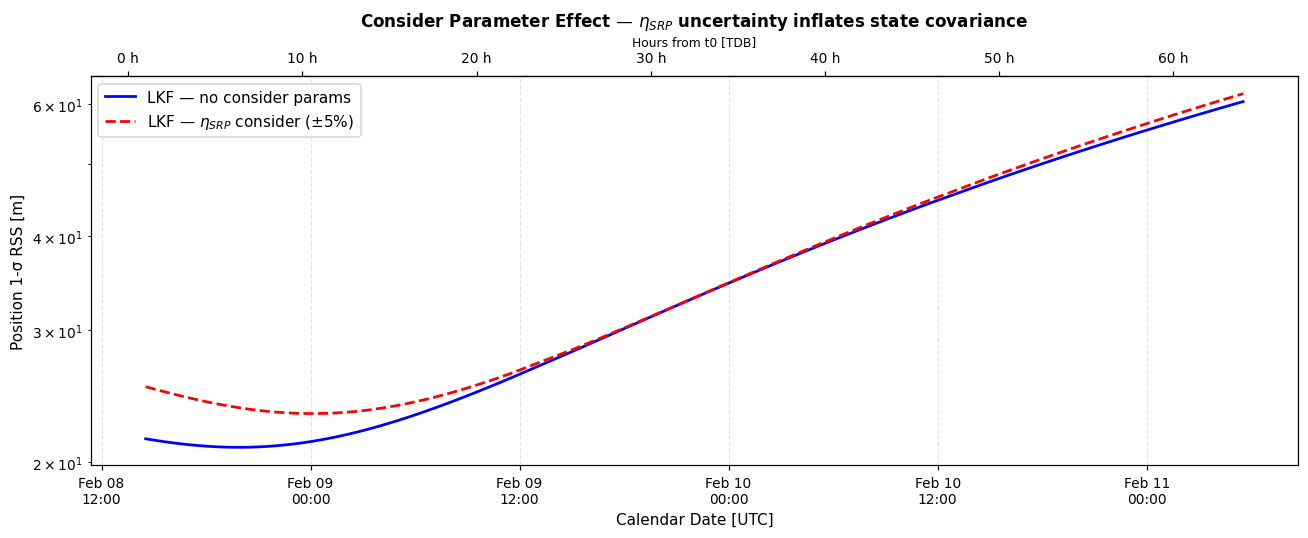

Mean consider / no-consider RSS ratio : 1.029  (> 1 confirms covariance inflation)
Arc-start  consider σ_pos RSS : 25.20 m   vs  21.48 m  (no consider)
Arc-end    consider σ_pos RSS : 62.03 m  vs  60.54 m  (no consider)


In [12]:
# ── Consider vs. no-consider — covariance comparison plot ─────────
# A consider parameter inflates the state covariance without changing the
# estimated state: the uncertainty in η_SRP propagates into position
# uncertainty, making the covariance a more conservative (honest) bound.
ep_cmp  = scb.EpochArray(sol_lkf.timestamps, sys='TDB')
P_ncp   = sol_lkf.propagate_covariance(ep_cmp)     # without consider
P_wcp   = sol_cp.propagate_covariance(ep_cmp)      # with consider η_SRP

rss_ncp = np.array([np.sqrt(np.sum(np.diag(P)[:3])) for P in P_ncp]) * 1e3   # m
rss_wcp = np.array([np.sqrt(np.sum(np.diag(P)[:3])) for P in P_wcp]) * 1e3   # m
dts_cmp = et2dt(sol_lkf.timestamps)

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(dts_cmp, rss_ncp, 'b-',  lw=1.8, label='LKF — no consider params')
ax.semilogy(dts_cmp, rss_wcp, 'r--', lw=1.8, label=r'LKF — $\eta_{SRP}$ consider (±5%)')
ax.set_ylabel('Position 1-σ RSS [m]')
ax.set_xlabel('Calendar Date [UTC]')
ax.set_title(
    r'Consider Parameter Effect — $\eta_{SRP}$ uncertainty inflates state covariance',
    fontweight='bold')
ax.legend(fontsize=10); fmt_cal(ax); add_hrs_axis(ax, t0_et)
plt.tight_layout(); plt.show()

ratio = rss_wcp.mean() / rss_ncp.mean()
print(f'Mean consider / no-consider RSS ratio : {ratio:.3f}  (> 1 confirms covariance inflation)')
print(f'Arc-start  consider σ_pos RSS : {rss_wcp[0]:.2f} m   vs  {rss_ncp[0]:.2f} m  (no consider)')
print(f'Arc-end    consider σ_pos RSS : {rss_wcp[-1]:.2f} m  vs  {rss_ncp[-1]:.2f} m  (no consider)')

## 8. Measurement Editing

Sequential filters support chi-squared outlier rejection via `FilterSettings`.
The same API and behaviour apply in SRIF and MissionSequence contexts.
See `advanced_IdealMSR_BatchOD.ipynb` for a detailed walkthrough of editing strategies
(chi2, lasso, date-range exclusion) and post-edit residual diagnostics.


## 9. Solution Saving and Full Analysis

Solution analysis — corner covariance plots, covariance propagation beyond the arc,
`SolutionOD` API reference, and file-saving via `OutputSettings` — is covered in full
in **`advanced_IdealMSR_BatchOD.ipynb`** (the API is identical for sequential filters).


## Summary

This notebook demonstrated the **complete sequential OD workflow** in Scarabaeus:

| Step | Class / Method | Notes |
|------|---------------|-------|
| LKF + SNC | `scb.LKF` + `ProcessNoiseSettings(type='SNC')` | Core sequential filter |
| Pre/post-fit residuals | `filter.prefit_residuals`, `filter.postfit_residuals` | Per-dataset dicts |
| SRIF | `scb.SRIF` | Numerically stable square-root form |
| RTS smoother | `filter.fit(if_sequential_smooth=True)` | Acausal backward pass |
| Multi-leg OD | `scb.MissionSequence` + `addLeg / addBurn` | Maneuver-spanning arcs |
| Consider params | `.param(..., estimation='considered')` | Covariance inflation only |

**See also:** `advanced_IdealMSR_BatchOD.ipynb` — batch OD, FOGM+DMC, corner plots,
covariance propagation, solution saving.
